# Exploratory Data Analysis — Student Dropout & Academic Success

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Same DATA_PATH logic as train_models.ipynb (resolves relative to model/ directory)
DATA_PATH = Path('..') / 'data' / 'data.csv'
df = pd.read_csv(DATA_PATH, sep=None, engine='python')
# Strip BOM from first column name if present
df.columns = [c.lstrip('\ufeff') for c in df.columns]

FEATURE_COLUMNS = [c for c in df.columns if c != 'Target']
numeric_cols = [c for c in df.select_dtypes(include=['number']).columns if c != 'Target']
NOMINAL_COLS = [c for c in numeric_cols
                if pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= 30]
NUMERIC_COLS = [c for c in FEATURE_COLUMNS if c not in NOMINAL_COLS]

CLASS_ORDER = ['Dropout', 'Enrolled', 'Graduate']
CLASS_PALETTE = {'Dropout': '#e15759', 'Enrolled': '#f28e2b', 'Graduate': '#4e79a7'}

print('Data loaded — shape:', df.shape)
print('Numeric cols:', len(NUMERIC_COLS), '| Nominal cols:', len(NOMINAL_COLS))

Data loaded — shape: (100, 37)
Numeric cols: 7 | Nominal cols: 29


## 1. Data Overview

In [2]:
print('=== Shape ===')
print(f'{df.shape[0]} rows × {df.shape[1]} columns')

print('\n=== Dtype Summary ===')
print(df.dtypes.value_counts().to_string())

print('\n=== Missing Values per Column ===')
missing = df.isna().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else 'No missing values.')

print('\n=== Duplicate Rows ===')
print(f'{df.duplicated().sum()} duplicate rows')

=== Shape ===
100 rows × 37 columns

=== Dtype Summary ===
int64      29
float64     7
object      1

=== Missing Values per Column ===
No missing values.

=== Duplicate Rows ===
0 duplicate rows


## 2. Univariate Analysis

### 2.1 Target Variable

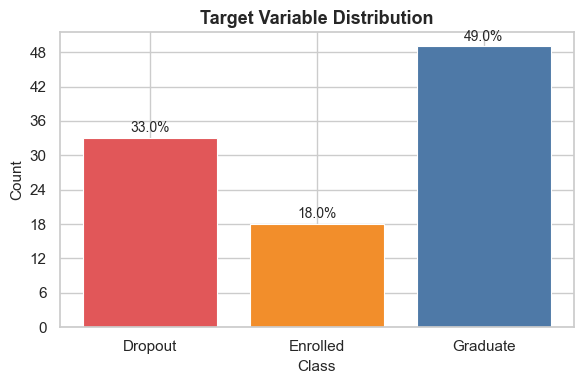

Target
Dropout     33
Enrolled    18
Graduate    49
Target
Dropout     33.0
Enrolled    18.0
Graduate    49.0


In [3]:
counts = df['Target'].value_counts().reindex(CLASS_ORDER)
pcts = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[CLASS_PALETTE[c] for c in counts.index], edgecolor='white', linewidth=0.8)
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(counts.to_string())
print(pcts.round(1).to_string())

### 2.2 Numeric Features

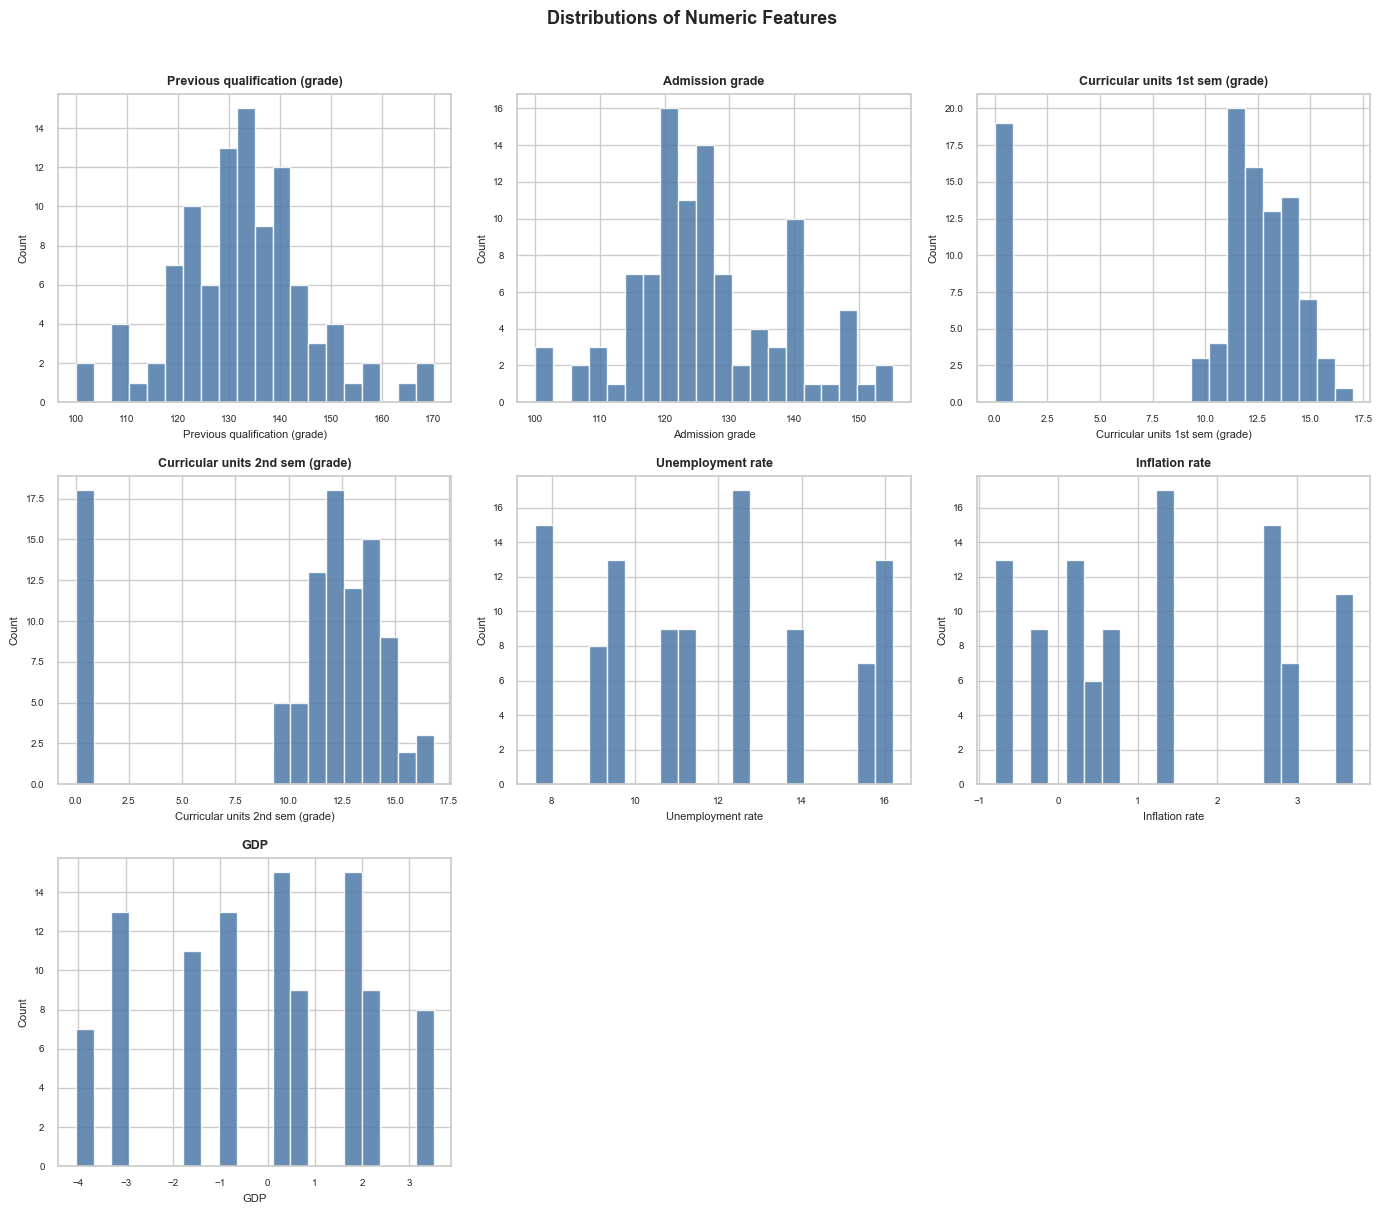

In [4]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=20, color='#4e79a7', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions of Numeric Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Categorical Features (EDA subset)

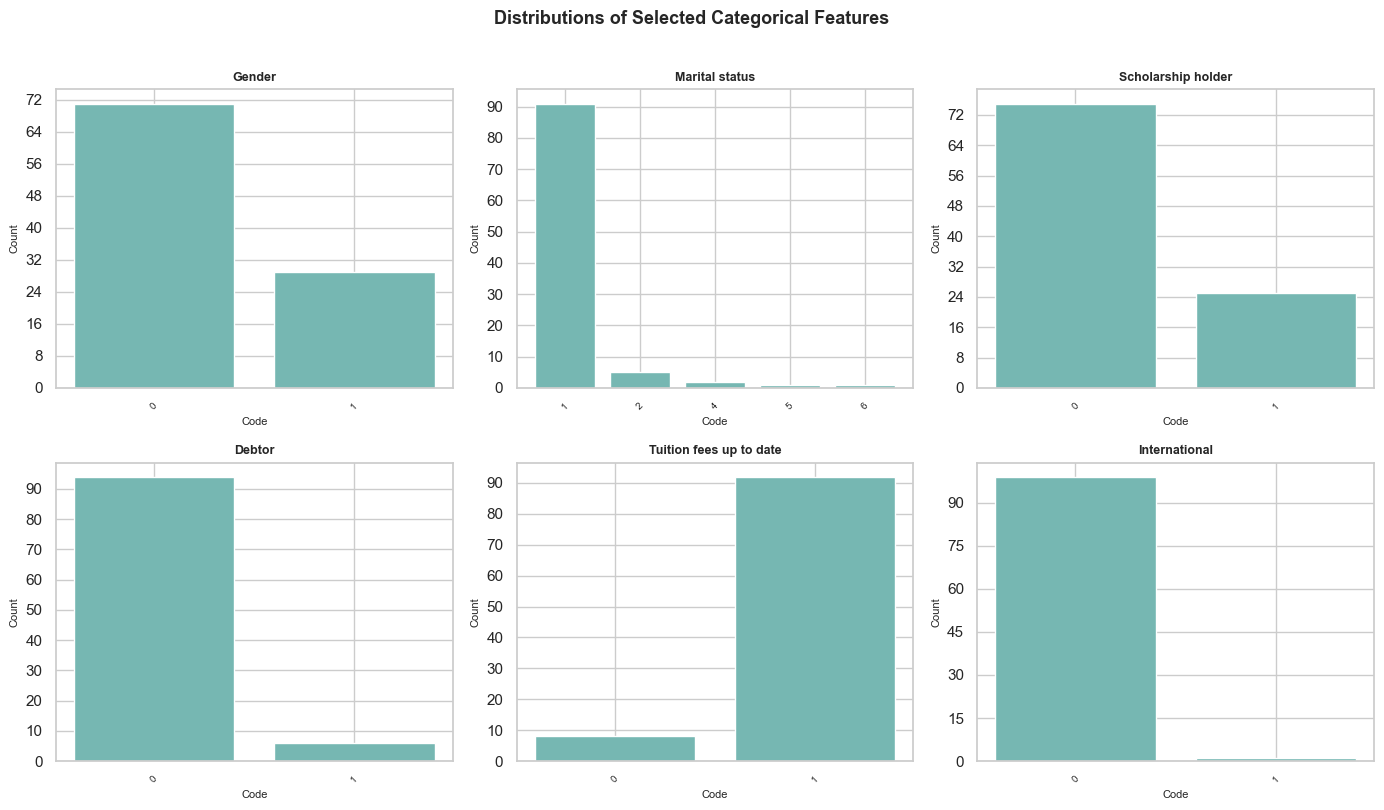

In [5]:
EDA_CAT_COLS = ['Gender', 'Marital status', 'Scholarship holder',
                'Debtor', 'Tuition fees up to date', 'International']
EDA_CAT_COLS = [c for c in EDA_CAT_COLS if c in df.columns]

BINARY_LABELS = {0: 'No / Female / Single', 1: 'Yes / Male / Married'}

ncols = 3
nrows = int(np.ceil(len(EDA_CAT_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(EDA_CAT_COLS):
    ax = axes[i]
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='#76b7b2', edgecolor='white')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Code', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions of Selected Categorical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Bivariate Analysis

### 3.1 Categorical Features vs Target

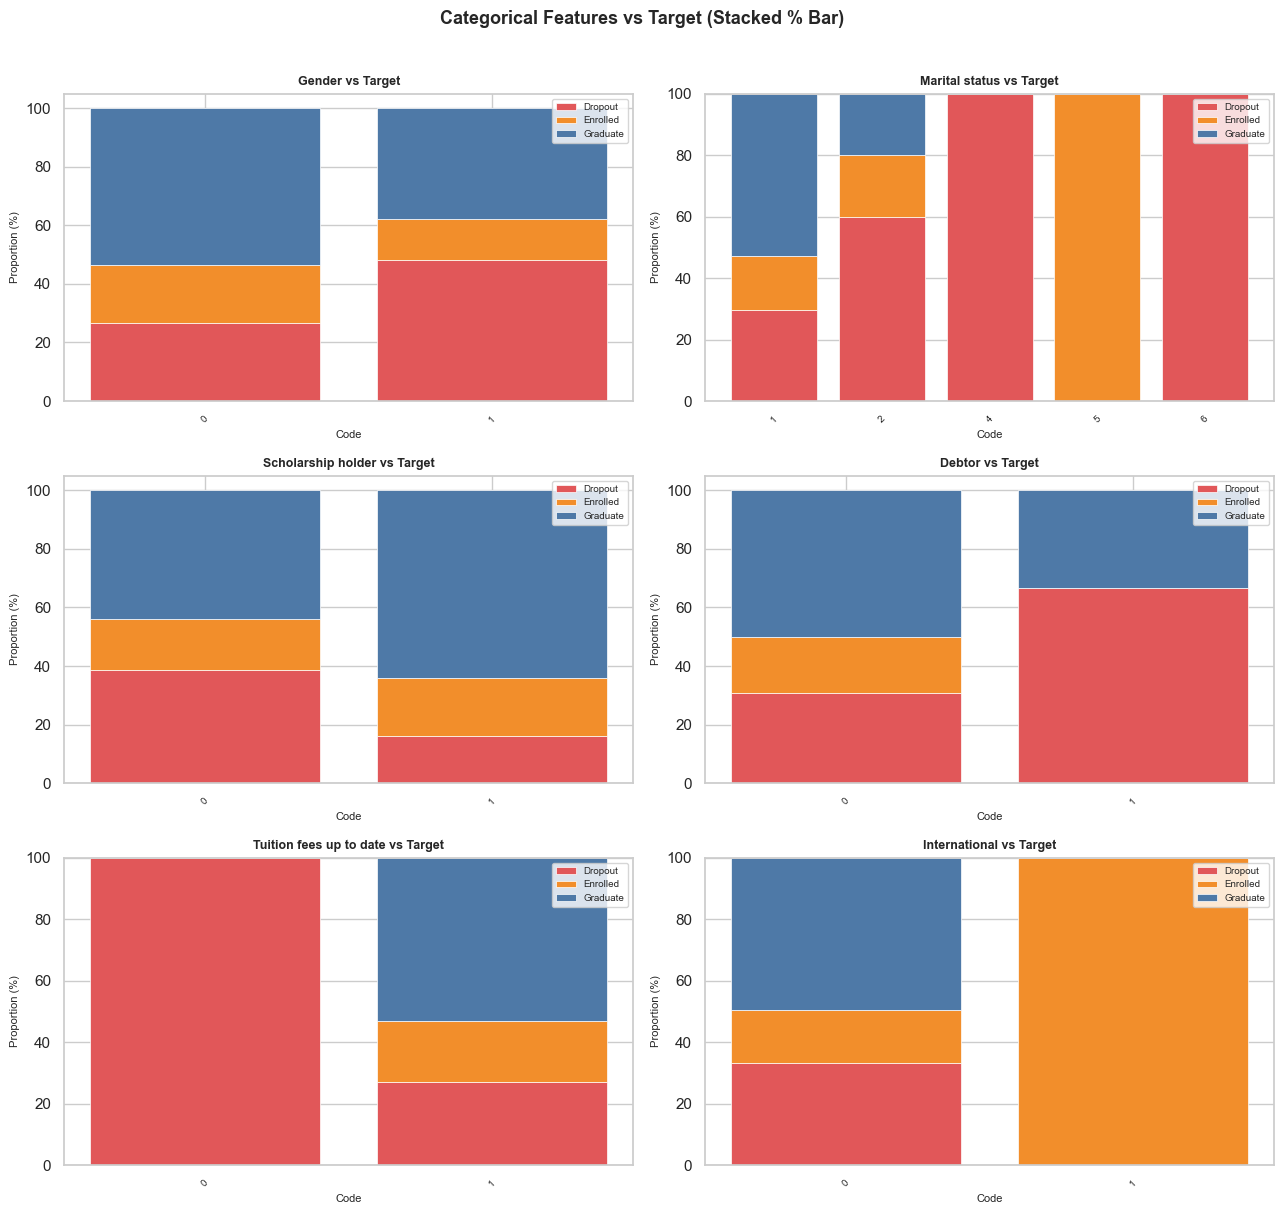

In [6]:
ncols = 2
nrows = int(np.ceil(len(EDA_CAT_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(EDA_CAT_COLS):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['Target']).reindex(columns=CLASS_ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    bottom = np.zeros(len(ct_pct))
    for cls in CLASS_ORDER:
        ax.bar(ct_pct.index.astype(str), ct_pct[cls],
               bottom=bottom, label=cls, color=CLASS_PALETTE[cls], edgecolor='white', linewidth=0.5)
        bottom += ct_pct[cls].values
    ax.set_title(f'{col} vs Target', fontsize=9, fontweight='bold')
    ax.set_xlabel('Code', fontsize=8)
    ax.set_ylabel('Proportion (%)', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7, loc='upper right')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Features vs Target (Stacked % Bar)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Numeric Features vs Target (Boxplots)

C:\Users\320168566\AppData\Local\Temp\ipykernel_1792\2655186360.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=CLASS_ORDER, patch_artist=True, notch=False,
C:\Users\320168566\AppData\Local\Temp\ipykernel_1792\2655186360.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=CLASS_ORDER, patch_artist=True, notch=False,
C:\Users\320168566\AppData\Local\Temp\ipykernel_1792\2655186360.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=CLASS_ORDER, patch_artist=True, notch=False,
C:\Users\320168566\AppData\Local\Temp\ipykerne

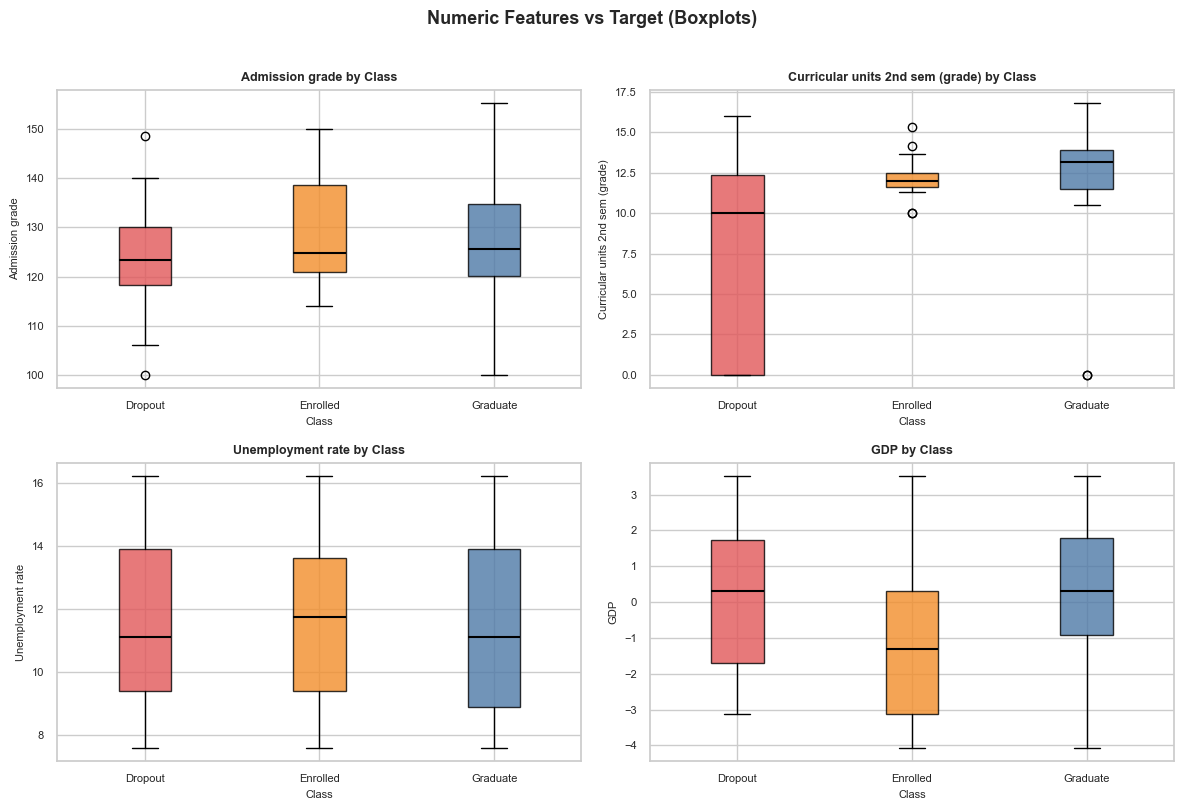

In [7]:
BOX_COLS = ['Admission grade', 'Curricular units 2nd sem (grade)',
            'Unemployment rate', 'GDP']
BOX_COLS = [c for c in BOX_COLS if c in df.columns]

ncols = 2
nrows = int(np.ceil(len(BOX_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(BOX_COLS):
    ax = axes[i]
    groups = [df.loc[df['Target'] == cls, col].dropna().values for cls in CLASS_ORDER]
    bp = ax.boxplot(groups, labels=CLASS_ORDER, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, cls in zip(bp['boxes'], CLASS_ORDER):
        patch.set_facecolor(CLASS_PALETTE[cls])
        patch.set_alpha(0.8)
    ax.set_title(f'{col} by Class', fontsize=9, fontweight='bold')
    ax.set_xlabel('Class', fontsize=8)
    ax.set_ylabel(col, fontsize=8)
    ax.tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric Features vs Target (Boxplots)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap (Numeric Features)

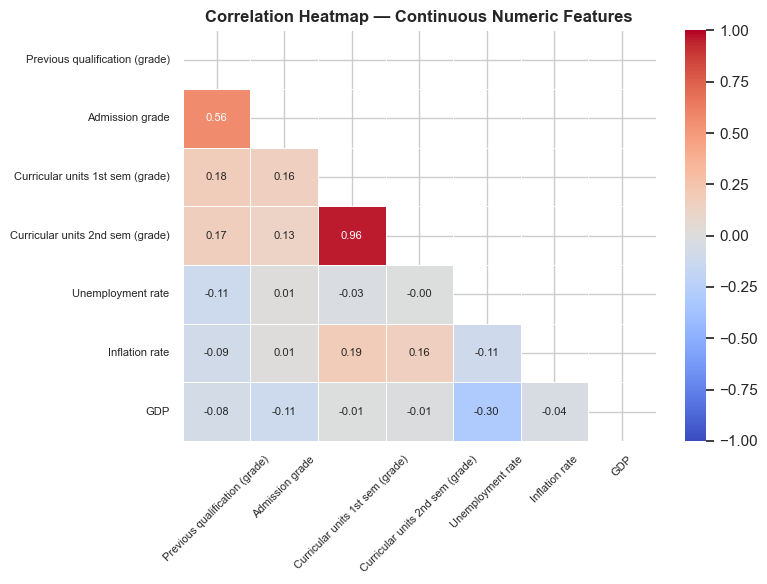

In [8]:
corr = df[NUMERIC_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Continuous Numeric Features', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

## 4. Outlier Check

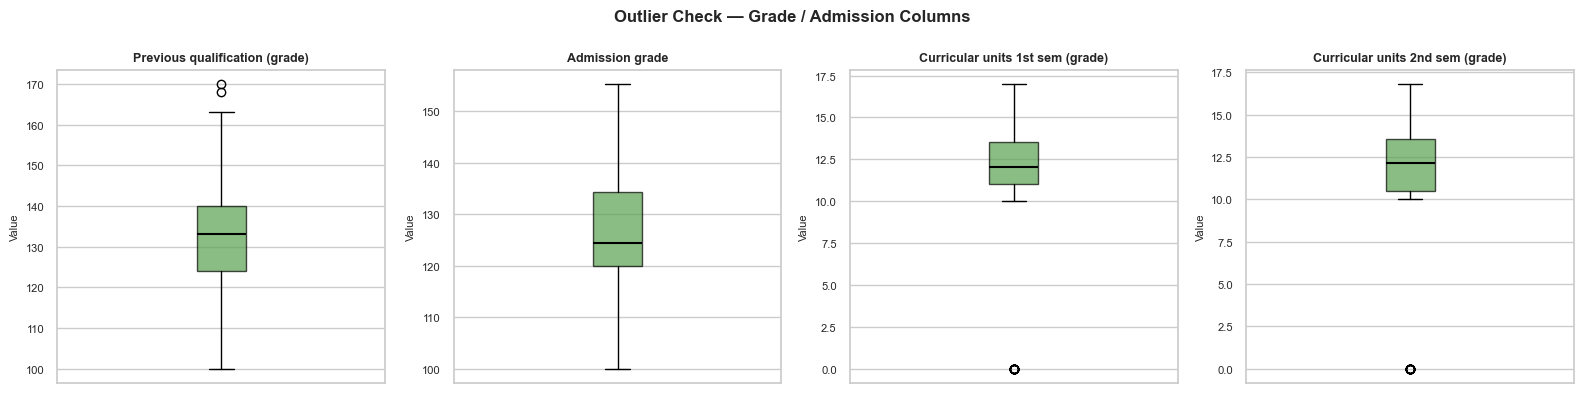


Preprocessing note (from train_models.ipynb):
  Numeric features → SimpleImputer(strategy='median') + StandardScaler.
  There is no explicit outlier removal step — extreme values are retained and
  only scaled/imputed. Outliers visible in the boxplots above are therefore
  present in the training data.



In [9]:
GRADE_UNIT_COLS = [c for c in NUMERIC_COLS
                  if 'grade' in c.lower() or 'admission' in c.lower()]

if GRADE_UNIT_COLS:
    fig, axes = plt.subplots(1, len(GRADE_UNIT_COLS),
                             figsize=(4 * len(GRADE_UNIT_COLS), 4))
    if len(GRADE_UNIT_COLS) == 1:
        axes = [axes]
    for ax, col in zip(axes, GRADE_UNIT_COLS):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#59a14f', alpha=0.7),
                   medianprops=dict(color='black', linewidth=1.5))
        ax.set_title(col, fontsize=9, fontweight='bold')
        ax.set_ylabel('Value', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.set_xticks([])
    fig.suptitle('Outlier Check — Grade / Admission Columns', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No grade/admission columns detected in NUMERIC_COLS.')

print("""
Preprocessing note (from train_models.ipynb):
  Numeric features → SimpleImputer(strategy='median') + StandardScaler.
  There is no explicit outlier removal step — extreme values are retained and
  only scaled/imputed. Outliers visible in the boxplots above are therefore
  present in the training data.
""")

## 5. Key Insights

The following bullets are each tied to a specific chart or statistic produced above.

- **Class imbalance (§2.1):** Graduate students make up ~49% of the sample, Dropout ~33%, and Enrolled ~18%. This moderate imbalance means macro-averaged recall is pulled down by the minority Enrolled class — consistent with the model performance reported in the README.

- **Admission & 2nd-semester grade separate classes best (§3.2):** Graduate students show noticeably higher median admission grades and 2nd-semester grades than Dropout students. This is the strongest numeric signal visible in the boxplots and explains why these features carry high coefficient weight in the Logistic Regression model.

- **Tuition fees up to date is a strong categorical predictor (§3.1):** Students with tuition fees up to date (code 1) have a substantially higher Graduate proportion and lower Dropout proportion than those in arrears — consistent with the README observation that this feature is one of the strongest Logistic Regression predictors.

- **Scholarship holders drop out less (§3.1):** The stacked bar for Scholarship holder shows that code 1 (scholarship) students have a higher Graduate share and lower Dropout share, suggesting financial support correlates with academic persistence.

- **Grade columns are correlated (§3.3):** Admission grade and 2nd-semester grade show moderate positive correlation, as do the two semester grade columns with each other. This multicollinearity is handled gracefully by Logistic Regression (via standardisation) but contributes to the instability seen in the single Decision Tree.

- **No missing values, no duplicates (§1):** The dataset is clean — no imputation actually fires during training on this sample, though the median-imputation step in `train_models.ipynb` is retained as a safety net for unseen data uploaded via the Streamlit app.